In [1]:
!pip install torch matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

In [13]:
def sparsemax(logits, dim=-1):
    logits = logits - logits.max(dim=dim, keepdim=True)[0]

    sorted_logits, _ = torch.sort(logits, descending=True, dim=dim)
    cumsum = torch.cumsum(sorted_logits, dim)

    range_vals = torch.arange(1, logits.size(dim)+1, device=logits.device).float()
    range_vals = range_vals.view([1]* (logits.dim()-1) + [-1])

    condition = 1 + range_vals * sorted_logits > cumsum
    k = condition.sum(dim=dim, keepdim=True)

    tau = (cumsum.gather(dim, k-1) - 1) / k.float()

    return torch.clamp(logits - tau, min=0)

In [14]:
class Attention(nn.Module):
    def __init__(self, d_model, use_sparsemax=False):
        super().__init__()
        self.use_sparsemax = use_sparsemax
        self.scale = math.sqrt(d_model)

    def forward(self, Q, K, V):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        if self.use_sparsemax:
            attn = sparsemax(scores, dim=-1)
        else:
            attn = F.softmax(scores, dim=-1)

        output = torch.matmul(attn, V)
        return output, attn

In [15]:
class SimpleTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, use_sparsemax=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.attention = Attention(d_model, use_sparsemax)
        self.fc = nn.Linear(d_model, 2)  # binary classification

    def forward(self, x):
        x = self.embedding(x)
        attn_output, attn_weights = self.attention(x, x, x)

        x = attn_output.mean(dim=1)  # pooling
        out = self.fc(x)

        return out, attn_weights

In [16]:
# synthetic dataset
def generate_data(num_samples=1000, seq_len=10, vocab_size=50):
    X = torch.randint(0, vocab_size, (num_samples, seq_len))
    y = (X.sum(dim=1) % 2).long()  # even/odd classification
    return X, y

X, y = generate_data()

In [17]:
def train_model(model, X, y, epochs=30):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        optimizer.zero_grad()

        output, attn = model(X)
        loss = criterion(output, y)

        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    return attn

In [18]:
model_softmax = SimpleTransformer(vocab_size=50, d_model=64, use_sparsemax=False)
attn_softmax = train_model(model_softmax, X, y)

Epoch 1, Loss: 0.6972
Epoch 2, Loss: 0.6964
Epoch 3, Loss: 0.6956
Epoch 4, Loss: 0.6948
Epoch 5, Loss: 0.6941
Epoch 6, Loss: 0.6934
Epoch 7, Loss: 0.6927
Epoch 8, Loss: 0.6920
Epoch 9, Loss: 0.6914
Epoch 10, Loss: 0.6908
Epoch 11, Loss: 0.6902
Epoch 12, Loss: 0.6896
Epoch 13, Loss: 0.6890
Epoch 14, Loss: 0.6884
Epoch 15, Loss: 0.6879
Epoch 16, Loss: 0.6874
Epoch 17, Loss: 0.6868
Epoch 18, Loss: 0.6863
Epoch 19, Loss: 0.6858
Epoch 20, Loss: 0.6854
Epoch 21, Loss: 0.6849
Epoch 22, Loss: 0.6844
Epoch 23, Loss: 0.6840
Epoch 24, Loss: 0.6835
Epoch 25, Loss: 0.6831
Epoch 26, Loss: 0.6827
Epoch 27, Loss: 0.6823
Epoch 28, Loss: 0.6819
Epoch 29, Loss: 0.6815
Epoch 30, Loss: 0.6811


In [19]:
model_sparsemax = SimpleTransformer(vocab_size=50, d_model=64, use_sparsemax=True)
attn_sparsemax = train_model(model_sparsemax, X, y)

Epoch 1, Loss: 0.7169
Epoch 2, Loss: 0.7148
Epoch 3, Loss: 0.7128
Epoch 4, Loss: 0.7109
Epoch 5, Loss: 0.7091
Epoch 6, Loss: 0.7074
Epoch 7, Loss: 0.7058
Epoch 8, Loss: 0.7043
Epoch 9, Loss: 0.7029
Epoch 10, Loss: 0.7015
Epoch 11, Loss: 0.7003
Epoch 12, Loss: 0.6991
Epoch 13, Loss: 0.6980
Epoch 14, Loss: 0.6970
Epoch 15, Loss: 0.6961
Epoch 16, Loss: 0.6952
Epoch 17, Loss: 0.6944
Epoch 18, Loss: 0.6936
Epoch 19, Loss: 0.6929
Epoch 20, Loss: 0.6923
Epoch 21, Loss: 0.6916
Epoch 22, Loss: 0.6911
Epoch 23, Loss: 0.6905
Epoch 24, Loss: 0.6900
Epoch 25, Loss: 0.6894
Epoch 26, Loss: 0.6890
Epoch 27, Loss: 0.6885
Epoch 28, Loss: 0.6880
Epoch 29, Loss: 0.6876
Epoch 30, Loss: 0.6871


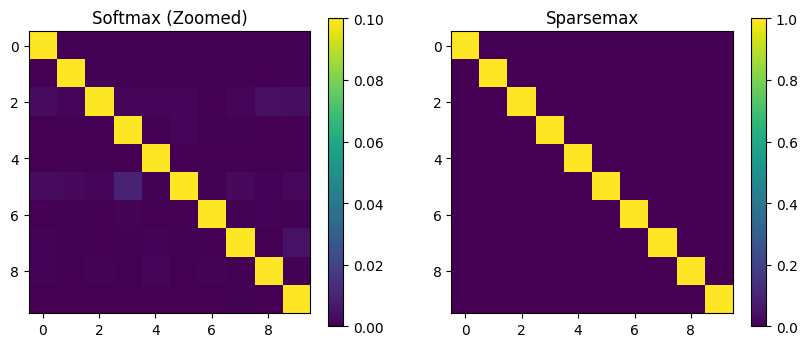

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Softmax (zoomed)
im1 = axs[0].imshow(attn_softmax[0].detach().numpy(), vmin=0, vmax=0.1)
axs[0].set_title("Softmax (Zoomed)")
plt.colorbar(im1, ax=axs[0])

# Sparsemax
im2 = axs[1].imshow(attn_sparsemax[0].detach().numpy(), vmin=0, vmax=1)
axs[1].set_title("Sparsemax")
plt.colorbar(im2, ax=axs[1])

plt.show()

In [22]:
def sparsity(attn):
    return (attn == 0).float().mean().item()

print("Softmax Sparsity:", sparsity(attn_softmax))
print("Sparsemax Sparsity:", sparsity(attn_sparsemax))

Softmax Sparsity: 0.0
Sparsemax Sparsity: 0.8817800283432007


In [23]:
def accuracy(model, X, y):
    output, _ = model(X)
    preds = torch.argmax(output, dim=1)
    return (preds == y).float().mean().item()

print("Softmax Accuracy:", accuracy(model_softmax, X, y))
print("Sparsemax Accuracy:", accuracy(model_sparsemax, X, y))

Softmax Accuracy: 0.5619999766349792
Sparsemax Accuracy: 0.5400000214576721
